# **Coffee Shop** | 11042025
---
`Copyright @ 2025. SMK Negeri 8 Malang. All rights reserved.`
- Lovi Adiva Alexandria
- Maulana El Jauziyah Al-Ghani

# **I. Data Understanding**

## ***A. Penjabaran Studi Kasus***

Kopi merupakan minuman yang memiliki banyak penggemar. Ada yang meminum kopi karena estetikanya, manfaatnya, untuk memulai hari, bahkan hanya sekedar ikut ikut saja. 

Kali ini, kami telah melakukan riset pada coffee shop di suatu wilayah dan menggabungkannya dalam suatu dataset yang berisikan detail dari toko-toko tersebut, seperti jumlah pelanggan, pendapatan, jumlah karyawan, dan sebagainya. Kami akan mengaplikasikan model machine learning untuk memprediksi pendapatan suatu coffee shop dari faktor-faktor yang diduga akan mempengaruhi pendapatan toko.

Harapannya nanti kami tidak hanya bisa membuat model yang dapat memberikan prediksi yang akurat, tapi juga bisa memberikan insight kepada para pemilik coffee shop untuk mengetahui faktor-faktor yang paling mempengaruhi pendapatan dan dapat memberikan saran untuk mengoptimalkan faktor tersebut.

## ***B. Import Libraries***

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## ***C. Import Dataset***

In [2]:
dataset = pd.read_csv("coffee_shop_revenue.csv")
dataset

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
0,152,6.74,14,4,106.62,97,1547.81
1,485,4.50,12,8,57.83,744,2084.68
2,398,9.09,6,6,91.76,636,3118.39
3,320,8.48,17,4,462.63,770,2912.20
4,156,7.44,17,2,412.52,232,1663.42
...,...,...,...,...,...,...,...
1995,372,6.41,11,4,466.11,913,2816.85
1996,105,3.01,11,7,12.62,235,337.97
1997,89,5.28,16,9,376.64,310,951.34
1998,403,9.41,7,12,452.49,577,4266.21


# **II. Data Preparation**

## ***A. Exploratory Data Analysis***

### 1. Inspeksi Daftar Variabel

In [3]:
dataset.columns

Index(['Number_of_Customers_Per_Day', 'Average_Order_Value',
       'Operating_Hours_Per_Day', 'Number_of_Employees',
       'Marketing_Spend_Per_Day', 'Location_Foot_Traffic', 'Daily_Revenue'],
      dtype='object')

Kami melihat bentuk atau karakteristik value dari setiap fitur dan mampu mengidentifikasi jenis data setiap fitur antara lain:

Target: `Daily_Revenue`

Numerik Continu:  `Average_Order_Value`, `Marketing_Spend_Per_Day`, `Location_Foot_Traffic`

Numerik Diskrit: `Number_of_Customers_Per_Day`, `Operating_Hours_Per_Day`, `Number_of_Employees`

Kategorikal Nominal: Tidak Ada

Kategorikal Ordinal: Tidak Ada

In [4]:
fitur_continu = ['Average_Order_Value', 'Marketing_Spend_Per_Day', 'Location_Foot_Traffic', 'Daily_Revenue']
fitur_diskrit = ['Number_of_Customers_Per_Day', 'Operating_Hours_Per_Day', 'Number_of_Employees', 'Daily_Revenue']

fitur_real = dataset.columns

### 2. Inspeksi Informasi Ringkas

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Number_of_Customers_Per_Day  2000 non-null   int64  
 1   Average_Order_Value          2000 non-null   float64
 2   Operating_Hours_Per_Day      2000 non-null   int64  
 3   Number_of_Employees          2000 non-null   int64  
 4   Marketing_Spend_Per_Day      2000 non-null   float64
 5   Location_Foot_Traffic        2000 non-null   int64  
 6   Daily_Revenue                2000 non-null   float64
dtypes: float64(3), int64(4)
memory usage: 109.5 KB


### 3. Inspeksi Statistik Deskriptif

In [6]:
dataset.describe()

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,274.296000,6.261215,11.667000,7.947000,252.614160,534.893500,1917.325940
std,129.441933,2.175832,3.438608,3.742218,141.136004,271.662295,976.202746
min,50.000000,2.500000,6.000000,2.000000,10.120000,50.000000,-58.950000
25%,164.000000,4.410000,9.000000,5.000000,130.125000,302.000000,1140.085000
50%,275.000000,6.300000,12.000000,8.000000,250.995000,540.000000,1770.775000
75%,386.000000,8.120000,15.000000,11.000000,375.352500,767.000000,2530.455000
max,499.000000,10.000000,17.000000,14.000000,499.740000,999.000000,5114.600000


### 4. Inspeksi Data NaN

In [7]:
dataset.isna().sum()

Number_of_Customers_Per_Day    0
Average_Order_Value            0
Operating_Hours_Per_Day        0
Number_of_Employees            0
Marketing_Spend_Per_Day        0
Location_Foot_Traffic          0
Daily_Revenue                  0
dtype: int64

### 5. Inspeksi Data Duplicated

In [8]:
dataset.duplicated().sum()

np.int64(0)

### 6. Dataset Sementara

#### *a. Copy Dataset Sementara*

In [9]:
dataset_copy = dataset.copy()

#### *b. Feature Engineering*

Fitur pendapatan bersih

In [10]:
dataset_copy["Clean_Daily_Revenue"] = dataset_copy["Daily_Revenue"] - dataset_copy["Marketing_Spend_Per_Day"]

Fitur pendapatan setiap karyawan per hari

In [11]:
dataset_copy["Revenue_per_Employee"] = dataset_copy["Clean_Daily_Revenue"] / dataset_copy["Number_of_Employees"]

Membuat Fitur `Customer Value`

In [12]:
dataset_copy["Customer_Value"] = dataset_copy["Number_of_Customers_Per_Day"] * dataset_copy["Average_Order_Value"]

#### *c. Data Preprocessing*

In [13]:
dataset_copy['Target'] = dataset_copy['Clean_Daily_Revenue'].apply(lambda x: "Low" if x < 1546 else("Medium" if x < 3092 else "High"))
map_target = {"Low" : 1, "Medium" : 2, "High" : 3}
dataset_copy['Target'] = dataset_copy['Target'].map(map_target)

In [14]:
dataset_copy['Target'].value_counts()

Target
1    1014
2     793
3     193
Name: count, dtype: int64

#### *d. Inspeksi Ulang Dataset Sementara*

In [15]:
dataset_copy

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue,Clean_Daily_Revenue,Revenue_per_Employee,Customer_Value,Target
0,152,6.74,14,4,106.62,97,1547.81,1441.19,360.297500,1024.48,1
1,485,4.50,12,8,57.83,744,2084.68,2026.85,253.356250,2182.50,2
2,398,9.09,6,6,91.76,636,3118.39,3026.63,504.438333,3617.82,2
3,320,8.48,17,4,462.63,770,2912.20,2449.57,612.392500,2713.60,2
4,156,7.44,17,2,412.52,232,1663.42,1250.90,625.450000,1160.64,1
...,...,...,...,...,...,...,...,...,...,...,...
1995,372,6.41,11,4,466.11,913,2816.85,2350.74,587.685000,2384.52,2
1996,105,3.01,11,7,12.62,235,337.97,325.35,46.478571,316.05,1
1997,89,5.28,16,9,376.64,310,951.34,574.70,63.855556,469.92,1
1998,403,9.41,7,12,452.49,577,4266.21,3813.72,317.810000,3792.23,3


In [16]:
dataset_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Number_of_Customers_Per_Day  2000 non-null   int64  
 1   Average_Order_Value          2000 non-null   float64
 2   Operating_Hours_Per_Day      2000 non-null   int64  
 3   Number_of_Employees          2000 non-null   int64  
 4   Marketing_Spend_Per_Day      2000 non-null   float64
 5   Location_Foot_Traffic        2000 non-null   int64  
 6   Daily_Revenue                2000 non-null   float64
 7   Clean_Daily_Revenue          2000 non-null   float64
 8   Revenue_per_Employee         2000 non-null   float64
 9   Customer_Value               2000 non-null   float64
 10  Target                       2000 non-null   int64  
dtypes: float64(6), int64(5)
memory usage: 172.0 KB


In [17]:
dataset_copy.describe()

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue,Clean_Daily_Revenue,Revenue_per_Employee,Customer_Value,Target
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,274.296000,6.261215,11.667000,7.947000,252.614160,534.893500,1917.325940,1664.711780,290.293842,1713.303160,1.589500
std,129.441933,2.175832,3.438608,3.742218,141.136004,271.662295,976.202746,950.092839,278.824977,1035.513668,0.659702
min,50.000000,2.500000,6.000000,2.000000,10.120000,50.000000,-58.950000,-75.210000,-37.605000,149.060000,1.000000
25%,164.000000,4.410000,9.000000,5.000000,130.125000,302.000000,1140.085000,901.630000,108.936813,872.902500,1.000000
50%,275.000000,6.300000,12.000000,8.000000,250.995000,540.000000,1770.775000,1531.445000,203.477923,1521.550000,1.000000
75%,386.000000,8.120000,15.000000,11.000000,375.352500,767.000000,2530.455000,2260.260000,366.977500,2346.695000,2.000000
max,499.000000,10.000000,17.000000,14.000000,499.740000,999.000000,5114.600000,4639.630000,1978.650000,4925.250000,3.000000


### 7. Inspeksi Rentang Data

In [18]:
def check_range(dataset, cols):
    for col in cols:

        Q1 = dataset[col].quantile(0.25)
        Q3 = dataset[col].quantile(0.75)
        IQR = Q3 - Q1

        print(f"Kolom: {col}")
        print(f"Q1: {Q1}")
        print(f"IQR: {IQR}")
        print(f"Q3: {Q3}\n")

check_range(dataset_copy, dataset_copy.columns)

Kolom: Number_of_Customers_Per_Day
Q1: 164.0
IQR: 222.0
Q3: 386.0

Kolom: Average_Order_Value
Q1: 4.41
IQR: 3.709999999999999
Q3: 8.12

Kolom: Operating_Hours_Per_Day
Q1: 9.0
IQR: 6.0
Q3: 15.0

Kolom: Number_of_Employees
Q1: 5.0
IQR: 6.0
Q3: 11.0

Kolom: Marketing_Spend_Per_Day
Q1: 130.125
IQR: 245.22750000000002
Q3: 375.3525

Kolom: Location_Foot_Traffic
Q1: 302.0
IQR: 465.0
Q3: 767.0

Kolom: Daily_Revenue
Q1: 1140.085
IQR: 1390.37
Q3: 2530.455

Kolom: Clean_Daily_Revenue
Q1: 901.63
IQR: 1358.63
Q3: 2260.26

Kolom: Revenue_per_Employee
Q1: 108.9368125
IQR: 258.0406875
Q3: 366.97749999999996

Kolom: Customer_Value
Q1: 872.9024999999999
IQR: 1473.7925000000002
Q3: 2346.695

Kolom: Target
Q1: 1.0
IQR: 1.0
Q3: 2.0



### 7. Univariate Analysis

#### *a. Inspeksi Distribusi Kelas Target*

In [19]:
target_counts = dataset_copy["Target"].value_counts()
target_counts

Target
1    1014
2     793
3     193
Name: count, dtype: int64

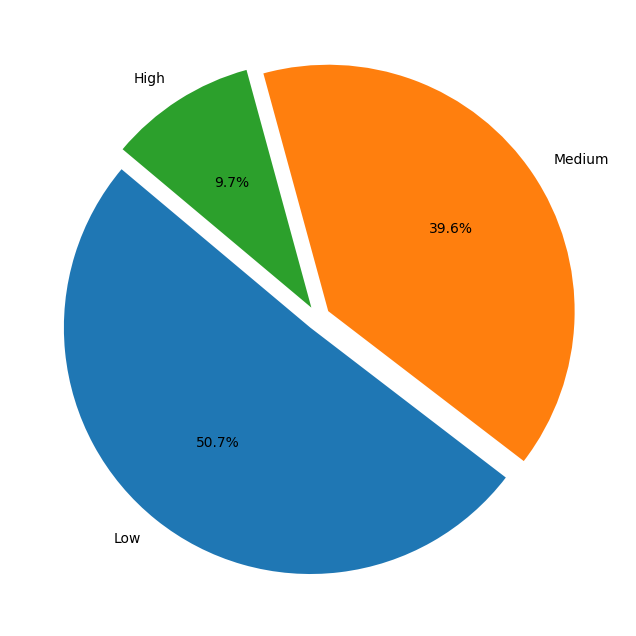

In [20]:
explodes = [0.05] * len(target_counts)
color = plt.get_cmap('tab10').colors

plt.figure(figsize=(8, 8))
plt.pie(
    target_counts,
    labels =target_counts.index.map({1: "Low", 2: "Medium", 3: "High"}),
    explode=explodes,
    colors=color,
    autopct="%1.1f%%",
    startangle=140
)
plt.show()

### 8. Bivariate Analysis

#### *a. Inspeksi Distribusi Fitur dengan Target*

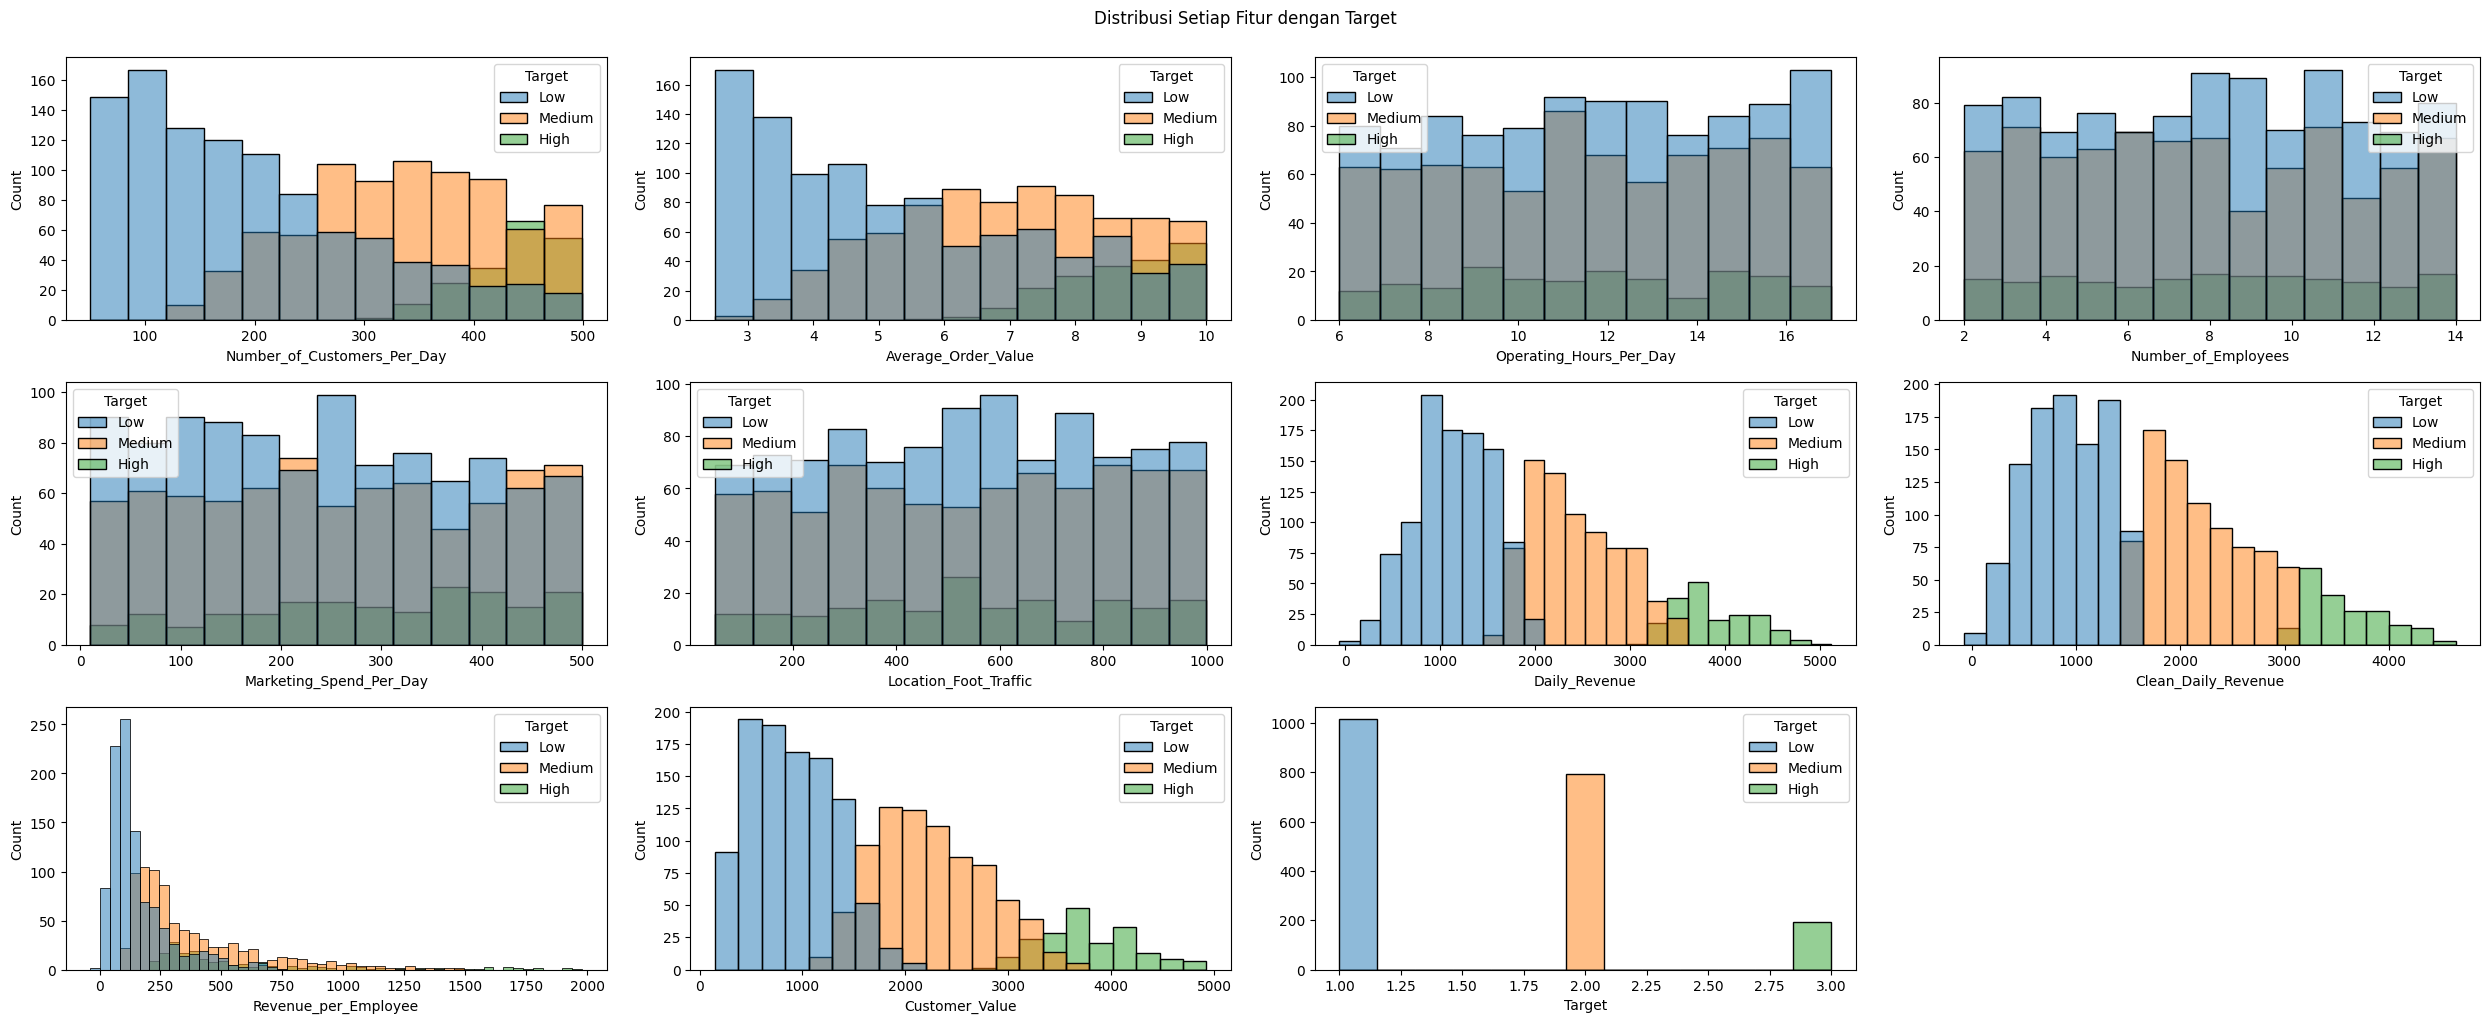

In [21]:
plt.figure(figsize=(25, 13))
for i, col in enumerate(dataset_copy):
    plt.subplot(4, 4, i+1)
    sns.histplot(x=dataset_copy[col], hue=dataset_copy["Target"].map({1: "Low", 2: "Medium", 3: "High"}))

plt.suptitle("Distribusi Setiap Fitur dengan Target", y=1)
plt.tight_layout()
plt.show()

### 9. Multivariate Analysis

#### *a. Inspeksi Distribusi Data dengan Target*

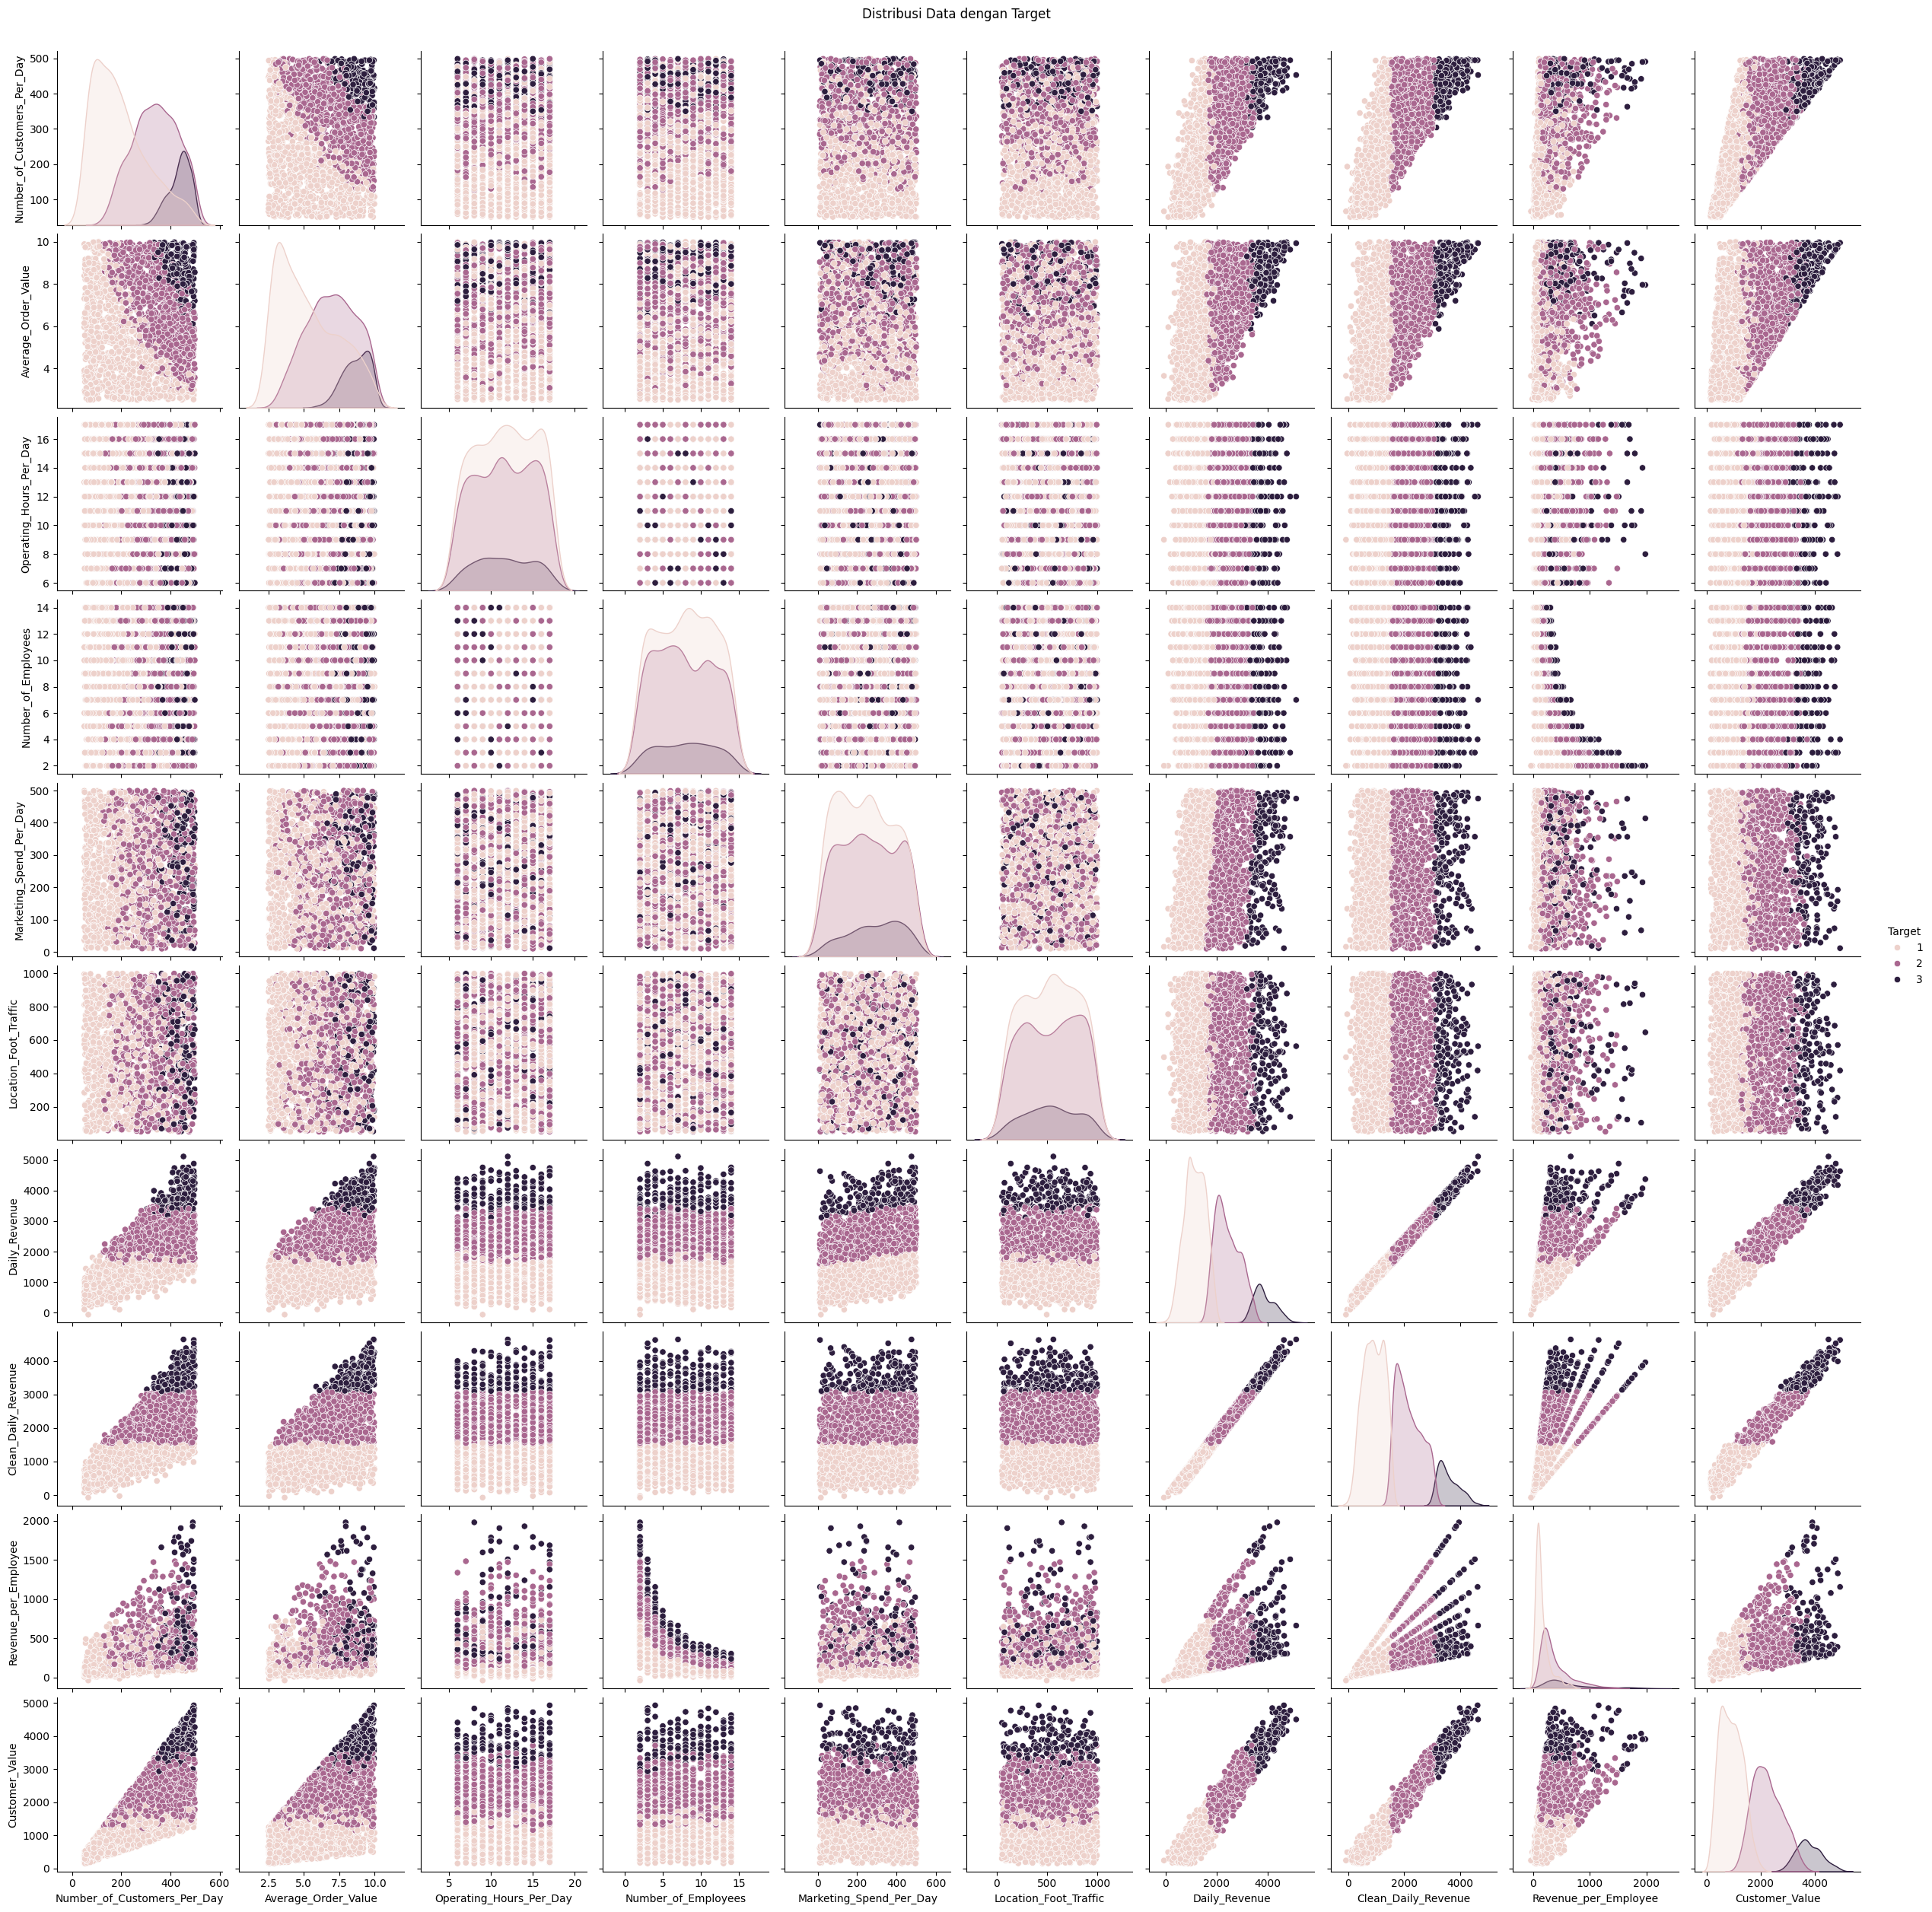

In [22]:
sns.pairplot(data=dataset_copy, hue="Target")
plt.suptitle("Distribusi Data dengan Target", y=1.01)
plt.show()

### 10. Inspeksi Korelasi

#### *a. Mutual Information*

In [23]:
real_feature = ["Average_Order_Value", "Operating_Hours_Per_Day", "Number_of_Customers_Per_Day", "Number_of_Employees", "Marketing_Spend_Per_Day", "Location_Foot_Traffic", "Daily_Revenue", "Clean_Daily_Revenue", "Customer_Value", "Revenue_per_Employee"]

def probability_distribution(x):
    unique, counts = np.unique(x, return_counts=True)
    return counts / counts.sum()

def calculate_entropy(x):
    probs = probability_distribution(x)
    return -np.sum(probs * np.log2(probs + 1e-10))

def mutual_information(x, y):
    xy_pairs = list(zip(x, y))
    unqiue_xy, counts_xy = np.unique(xy_pairs, return_counts=True)
    probs_xy = counts_xy / counts_xy.sum()
    entropy_xy = -np.sum(probs_xy * np.log2(probs_xy + 1e-10))

    entropy_x = calculate_entropy(x)
    entropy_y = calculate_entropy(y)
    return entropy_x + entropy_y - entropy_xy

fitur = dataset_copy[real_feature]
target = dataset_copy["Target"]

mi_scores = {col: mutual_information(fitur[col].values, target.values) for col in fitur.columns}
mi_df = pd.DataFrame(list(mi_scores.items()), columns=["Feature", "Mutual Information"])
mi_df = mi_df.sort_values(by="Mutual Information", ascending=False)
mi_df

,Feature,Mutual Information
9,Revenue_per_Employee,5.158156
7,Clean_Daily_Revenue,5.158156
6,Daily_Revenue,5.157656
8,Customer_Value,5.143656
4,Marketing_Spend_Per_Day,5.142156
5,Location_Foot_Traffic,4.416673
0,Average_Order_Value,4.307086
2,Number_of_Customers_Per_Day,3.980530
3,Number_of_Employees,1.765812
1,Operating_Hours_Per_Day,1.465655


C:\Users\RyzQ\AppData\Local\Temp\ipykernel_38752\643596418.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x="Mutual Information", y="Feature", palette="viridis")


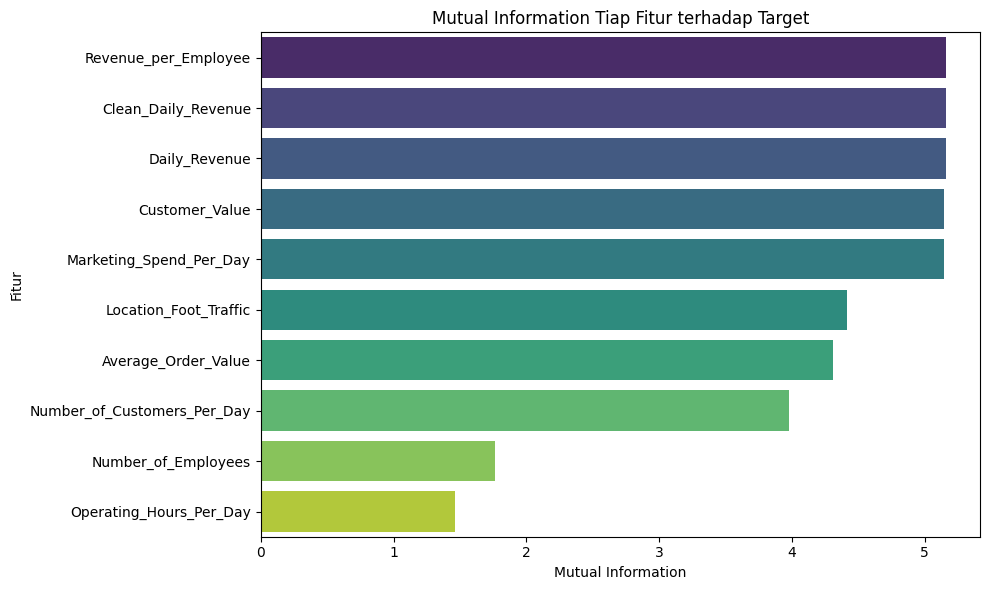

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(data=mi_df, x="Mutual Information", y="Feature", palette="viridis")

plt.title("Mutual Information Tiap Fitur terhadap Target")
plt.xlabel("Mutual Information")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()

#### *b. Kendall Method*

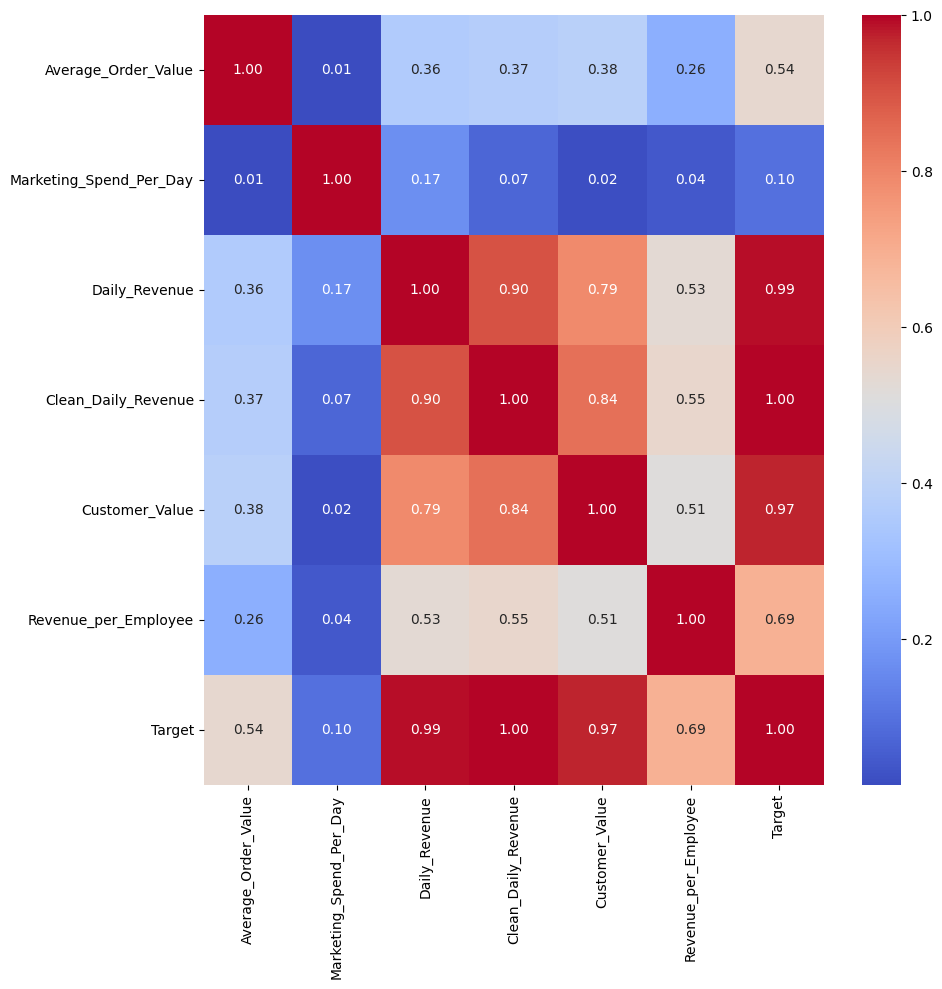

In [25]:
def kendall_method(x, y):
    n = len(x)
    concordant = 0
    disconcordant = 0

    for i in range(n - 1 ):
        for j in range(i + 1, n):

            x_diff = x[i] - x[j]
            y_diff = y[i] - y[j]

            if x_diff * y_diff > 0:
                concordant += 1
            elif x_diff * y_diff < 0:
                disconcordant += 1
    
    if (concordant - disconcordant) == 0:
        return 0
    
    return (concordant - disconcordant) / (concordant + disconcordant)

fitur_continu_real = ['Average_Order_Value', 'Marketing_Spend_Per_Day', 'Daily_Revenue', "Clean_Daily_Revenue", "Customer_Value", "Revenue_per_Employee", "Target"]
corr_matrix = pd.DataFrame(index=fitur_continu_real, columns=fitur_continu_real)

for col1 in fitur_continu_real:
    for col2 in fitur_continu_real:
        corr_matrix.loc[col1, col2] = kendall_method(dataset_copy[col1].values, dataset_copy[col2].values)

corr_matrix = corr_matrix.astype(float)

plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap = "coolwarm")
plt.show()

#### *c. Chi-square Method*

In [26]:
def chi_square_test(data, col1, col2):
    observed = pd.crosstab(data[col1], data[col2])

    total = observed.values.sum()
    row_totals = observed.sum(axis=1).values.reshape(-1, 1)
    col_totals = observed.sum(axis=0).values.reshape(1, -1)

    expected = row_totals @ col_totals / total
    chi_square = ((observed.values - expected) ** 2 / expected).sum()
    dof = (observed.shape[0] - 1) * (observed.shape[1] - 1)

    print(f"Feature: {col1} | Chi-square Score: {chi_square:.2f}")
    return chi_square, dof

chi_scores = []

fitur_diskrit =['Number_of_Customers_Per_Day', 'Operating_Hours_Per_Day', 'Number_of_Employees', 'Location_Foot_Traffic', 'Marketing_Spend_Per_Day', "Target"]

for col in fitur_diskrit:
    chi, dof = chi_square_test(dataset_copy, col, 'Target')
    chi_scores.append((col, chi))

chi_df = pd.DataFrame(chi_scores, columns=["Feature", "Chi-Square Score"])
chi_df = chi_df.sort_values(by="Chi-Square Score", ascending=False)

Feature: Number_of_Customers_Per_Day | Chi-square Score: 1836.71
Feature: Operating_Hours_Per_Day | Chi-square Score: 17.42
Feature: Number_of_Employees | Chi-square Score: 16.54
Feature: Location_Foot_Traffic | Chi-square Score: 1596.81
Feature: Marketing_Spend_Per_Day | Chi-square Score: 3945.27
Feature: Target | Chi-square Score: 4000.00


C:\Users\RyzQ\AppData\Local\Temp\ipykernel_38752\3289514411.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=chi_df, x="Feature", y="Chi-Square Score", palette="magma")


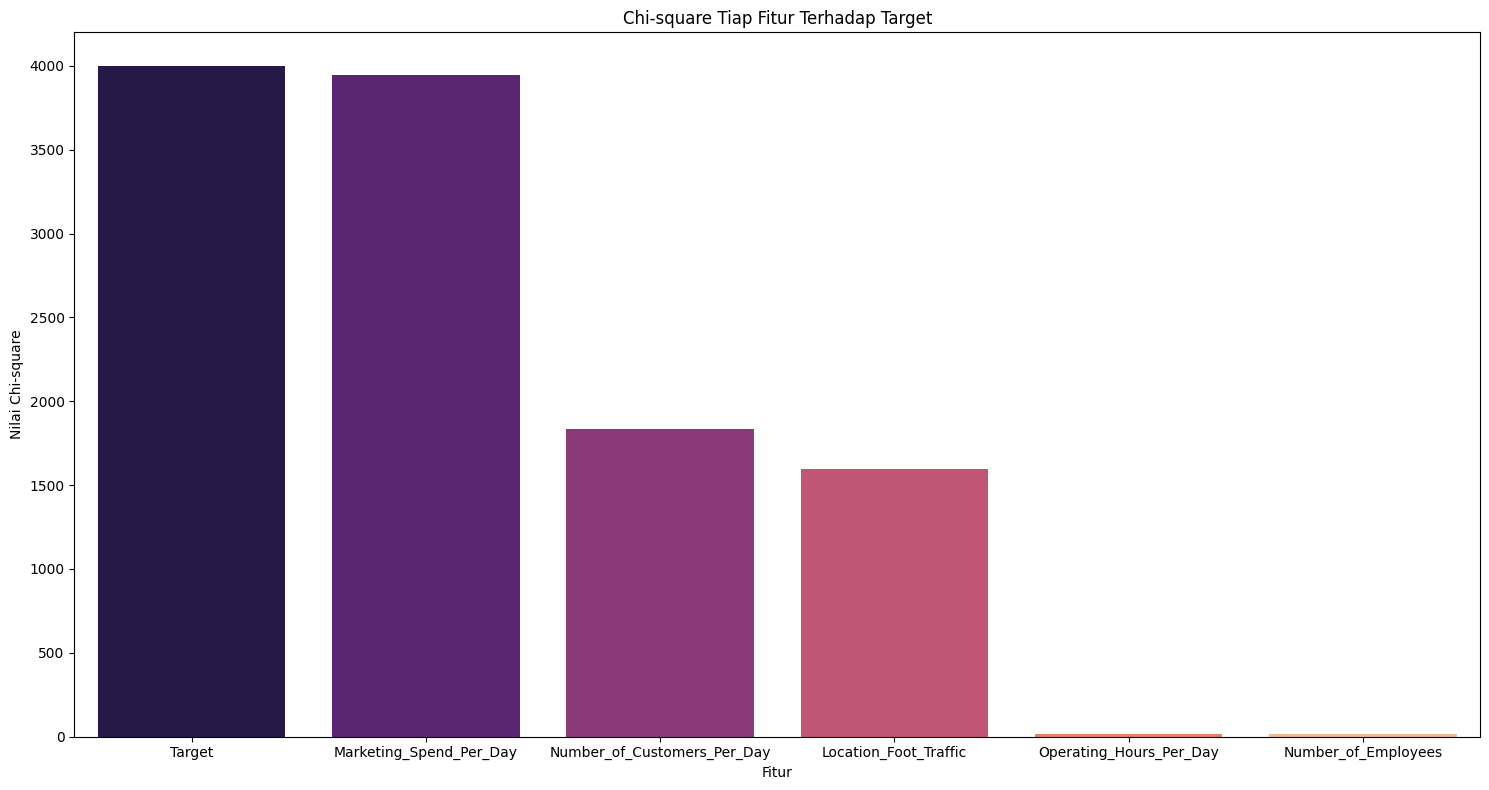

In [27]:
plt.figure(figsize=(15, 8))
sns.barplot(data=chi_df, x="Feature", y="Chi-Square Score", palette="magma")

plt.title("Chi-square Tiap Fitur Terhadap Target")
plt.xlabel("Fitur")
plt.ylabel("Nilai Chi-square")
plt.tight_layout()
plt.show()

#### *d. Pearson Method*

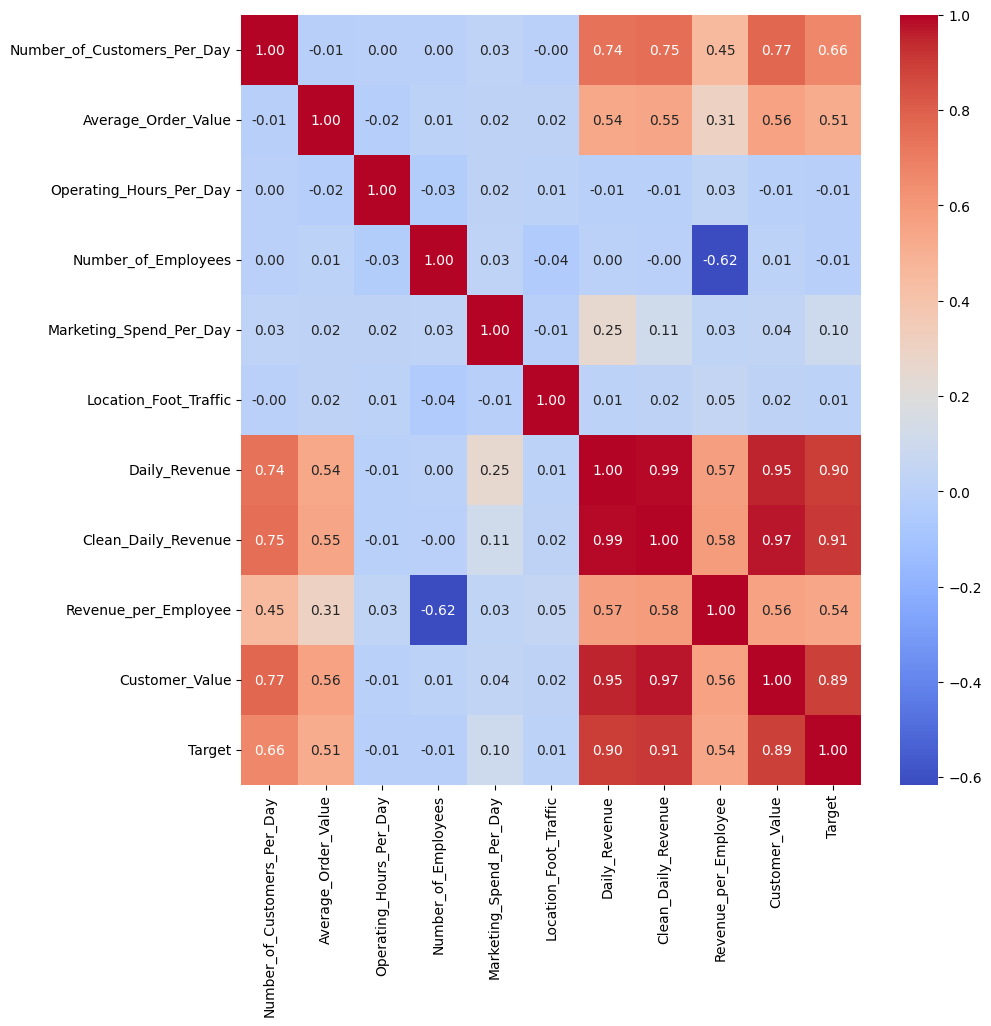

In [28]:
plt.figure(figsize=(10,10))
sns.heatmap(dataset_copy.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

### 11. Inspeksi Outlier

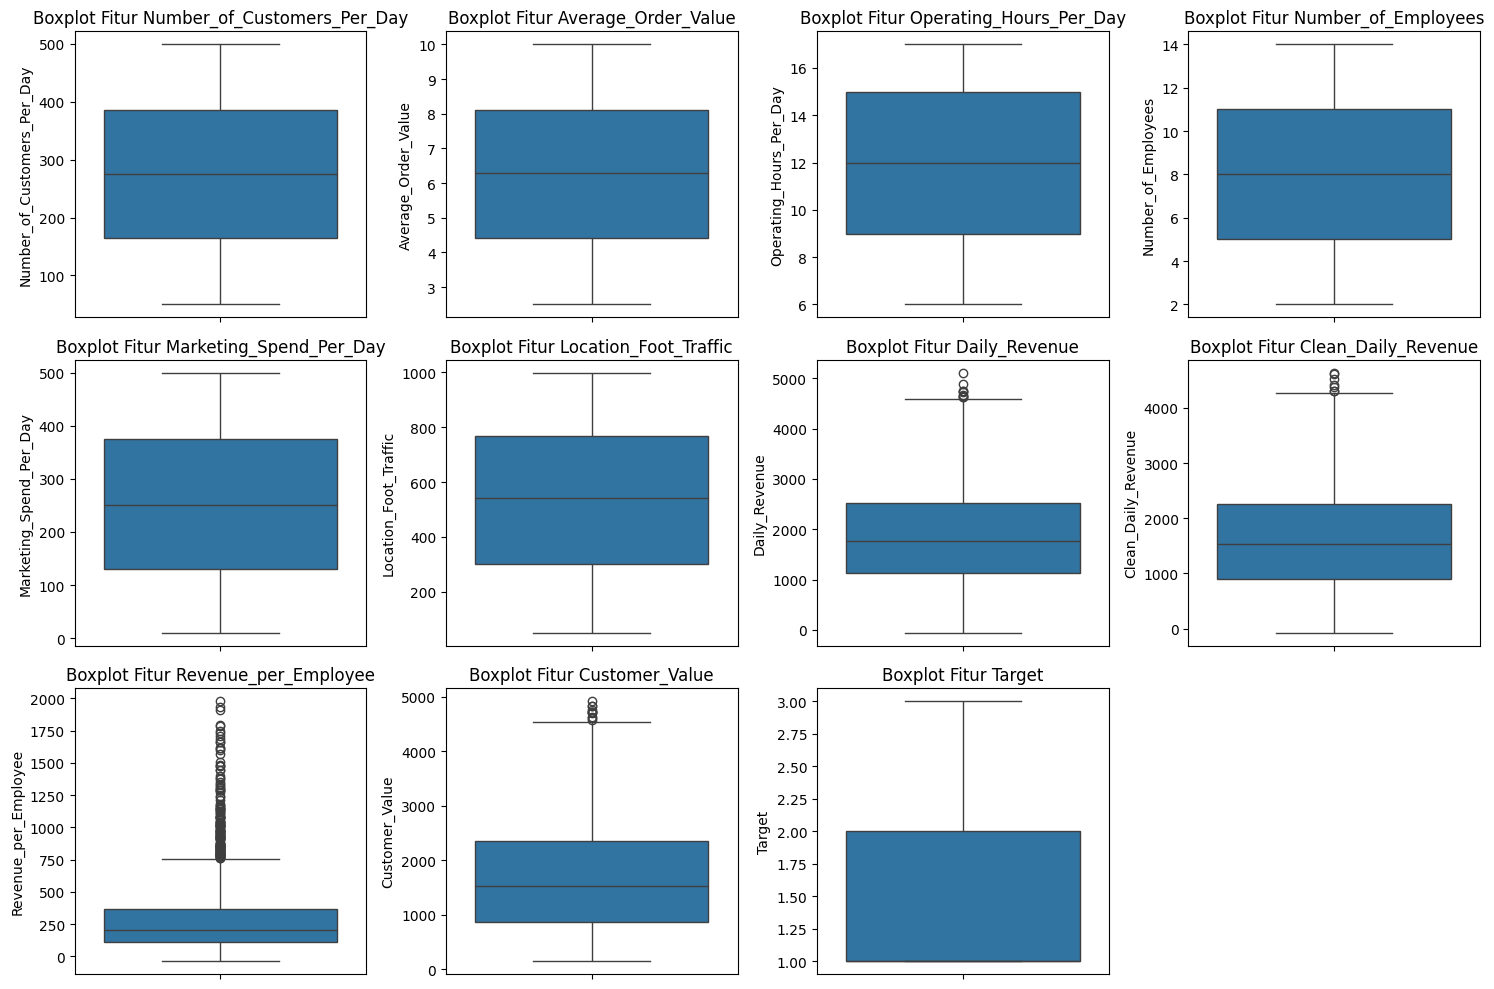

In [29]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(dataset_copy.select_dtypes(include=["number"]).columns):
    plt.subplot(3, 4, i+1)
    sns.boxplot(y=dataset_copy[col])
    plt.title(f"Boxplot Fitur {col}")

plt.tight_layout()
plt.show()

### 12. Insight dari Analisa

Setelah melakukan proses analisis pada step EDA, kami dapat memberikan beberapa kesimpulan yang kami dapatkan:

1. Yang paling menentukan apakah suatu coffee shop ramai atau tidak itu berdasarkan berapa banyak rata-rata customer yang datang perharinya.

2. Faktor-faktor lain yang mendukung revenue suatu coffee shop adalah berapa transaksi per-pelanggan, berapa budget marketing yang dikeluarkan, dan berapa revenue yang didapatkan perhari.

3. Meskipun secara logis, semakin banyak budget yang dikeluarkan berarti semakin banyak customer, dataset membuktikan bahwa fitur Marketing Spend tidak berkorelasi dengan customer, yang berarti budget yang dikeluarkan tidak menjamin banyaknya customer yang akan datang.

4. Jarak penghasilan bersih dengan penghasilan kotor per harinya tidak jauh berbeda, dikarenakan biaya yang dikeluarkan untuk marketing tidak sebanyak itu.

5. Semakin banyak revenue yang dihasilkan akan memunculkan setidaknya niat dari pemilik coffee shop untuk menambah budget marketing.

## ***B. Feature Selection***

Berdasarkan analisa yang telah dilakukan, kami memutuskan untuk mengambil variabel berikut sebagai fitur:
1. `Number_of_Customers_Per_Day`
2. `Average_Order_Value`
3. `Daily_Revenue`
4. `Customer_Value`
5. `Revenue_per_Employee`

In [30]:
feature_cols = ["Number_of_Customers_Per_Day", "Average_Order_Value", "Daily_Revenue", "Customer_Value", "Revenue_per_Employee"]

## ***C. Data Transformation***

### 1. Feature Engineering

Fitur pendapatan bersih

In [31]:
dataset["Clean_Daily_Revenue"] = dataset["Daily_Revenue"] - dataset["Marketing_Spend_Per_Day"]

Fitur pendapatan setiap karyawan per hari

In [32]:
dataset["Revenue_per_Employee"] = dataset["Clean_Daily_Revenue"] / dataset["Number_of_Employees"]

Fitur potensi pendapatan dalam sehari

In [33]:
dataset["Customer_Value"] = dataset["Number_of_Customers_Per_Day"] * dataset["Average_Order_Value"]

## ***C. Data Preprocessing***

### 1. Target Encoding

In [34]:
dataset['Target'] = dataset['Clean_Daily_Revenue'].apply(lambda x: "Low" if x < 1546 else("Medium" if x < 3092 else "High"))
dataset['Target'] = dataset['Target'].map(map_target)

### 2. Inspeksi Ulang Dataset

In [35]:
dataset

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue,Clean_Daily_Revenue,Revenue_per_Employee,Customer_Value,Target
0,152,6.74,14,4,106.62,97,1547.81,1441.19,360.297500,1024.48,1
1,485,4.50,12,8,57.83,744,2084.68,2026.85,253.356250,2182.50,2
2,398,9.09,6,6,91.76,636,3118.39,3026.63,504.438333,3617.82,2
3,320,8.48,17,4,462.63,770,2912.20,2449.57,612.392500,2713.60,2
4,156,7.44,17,2,412.52,232,1663.42,1250.90,625.450000,1160.64,1
...,...,...,...,...,...,...,...,...,...,...,...
1995,372,6.41,11,4,466.11,913,2816.85,2350.74,587.685000,2384.52,2
1996,105,3.01,11,7,12.62,235,337.97,325.35,46.478571,316.05,1
1997,89,5.28,16,9,376.64,310,951.34,574.70,63.855556,469.92,1
1998,403,9.41,7,12,452.49,577,4266.21,3813.72,317.810000,3792.23,3


In [36]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Number_of_Customers_Per_Day  2000 non-null   int64  
 1   Average_Order_Value          2000 non-null   float64
 2   Operating_Hours_Per_Day      2000 non-null   int64  
 3   Number_of_Employees          2000 non-null   int64  
 4   Marketing_Spend_Per_Day      2000 non-null   float64
 5   Location_Foot_Traffic        2000 non-null   int64  
 6   Daily_Revenue                2000 non-null   float64
 7   Clean_Daily_Revenue          2000 non-null   float64
 8   Revenue_per_Employee         2000 non-null   float64
 9   Customer_Value               2000 non-null   float64
 10  Target                       2000 non-null   int64  
dtypes: float64(6), int64(5)
memory usage: 172.0 KB


## ***D. Splitting Dataset***

In [37]:
def stratified_split_data(dataset, target_column, training_size=0.8, random_state=42, frac=1):
    np.random.seed(random_state)
    train_list, test_list = [], []

    for class_value in dataset[target_column].unique():
        class_data = dataset[dataset[target_column] == class_value]
        class_data = class_data.sample(random_state=random_state, frac=frac)

        split_idx = int(len(class_data) * training_size)
        train_list.append(class_data.iloc[:split_idx])
        test_list.append(class_data[split_idx:])

    train_set = pd.concat(train_list).reset_index(drop=True)
    test_set = pd.concat(test_list).reset_index(drop=True)
    return train_set, test_set

dataset_training, dataset_testing = stratified_split_data(dataset, "Target")

## ***E. Data Oversampling***

In [38]:
dataset_training['Target'].value_counts()

Target
1    811
2    634
3    154
Name: count, dtype: int64

In [39]:
def apply_smote_manual(dataset, target_column, additional_size=None):
    classes = dataset[target_column].value_counts()
    resampled_data = [dataset]
    
    for label, size in classes.items():
        if additional_size and additional_size.get(label, 0) > 0:
            minority_class_data = dataset[dataset[target_column] == label]
            additional_samples = minority_class_data.sample(n=additional_size[label], replace=True, random_state=42)
            resampled_data.append(additional_samples)
    
    final_dataset = pd.concat(resampled_data).sample(frac=1, random_state=42).reset_index(drop=True)
    return final_dataset

additional_samples = {2: 40, 1:40}

dataset_training = apply_smote_manual(dataset_training, 'Target', additional_samples)

In [40]:
dataset_training['Target'].value_counts()

Target
1    851
2    674
3    154
Name: count, dtype: int64

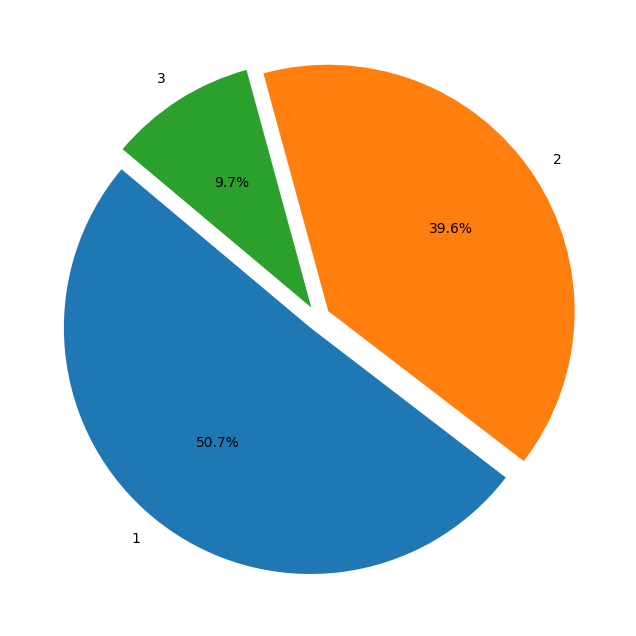

In [41]:
explodes = [0.05] * len(target_counts)
color = plt.get_cmap('tab10').colors

plt.figure(figsize=(8, 8))
plt.pie(
    target_counts,
    labels =target_counts.index,
    explode=explodes,
    colors=color,
    autopct="%1.1f%%",
    startangle=140
)
plt.show()

## ***F. Feature Target Declaration***

In [42]:
X_train = dataset_training[feature_cols]
X_test = dataset_testing[feature_cols]

y_train = dataset_training["Target"]
y_test = dataset_testing["Target"]

## ***G. Dimension Reduction***

### 1. Principal Component Analysis

In [43]:
def pca_fit(X, n_components):
    X_mean = np.mean(X, axis=0)
    X_centered = X - X_mean
    cov = np.cov(X_centered, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]

    components = eigenvectors[:, :n_components]

    X_pca = np.dot(X_centered, components)
    explained_variance = eigenvalues[:n_components]
    return X_pca, components, X_mean, explained_variance

def pca_transform(X, components, X_mean):
    X_centered = X - X_mean
    return np.dot(X_centered, components)

### 2. Multiple Correspondence Analysis

In [44]:
def mca_fit(X_cat, n_components):
    X_dummies = pd.get_dummies(X_cat)
    X_matrix = X_dummies.to_numpy()
    
    row_sums = X_matrix.sum(axis=1, keepdims=True)
    col_sums = X_matrix.sum(axis=0, keepdims=True)
    total = X_matrix.sum()
    
    expected = row_sums @ col_sums / total
    Z = (X_matrix - expected) / np.sqrt(expected)

    U, S, VT = np.linalg.svd(Z, full_matrices=False)
    X_mca = U[:, :n_components] * S[:n_components]
    components = VT[:n_components, :]
    
    return X_mca, components, X_dummies.columns

def mca_transform(X_cat, components, dummy_columns):
    X_dummies = pd.get_dummies(X_cat)
    X_dummies = X_dummies.reindex(columns=dummy_columns, fill_value=0)
    
    X_matrix = X_dummies.to_numpy()
    row_sums = X_matrix.sum(axis=1, keepdims=True)
    col_sums = X_matrix.sum(axis=0, keepdims=True)
    total = X_matrix.sum()
    expected = row_sums @ col_sums / total
    Z = (X_matrix - expected) / np.sqrt(expected)
    
    X_proj = Z @ components.T
    return X_proj

### 3. Factor Analysis of Mixed Data

In [45]:
def famd_fit_auto(df, n_components):
    num_cols = df.select_dtypes(include=["float"]).columns
    cat_cols = df.select_dtypes(include=["int", "object", "category"]).columns

    X_num = df[num_cols].to_numpy()
    X_cat = df[cat_cols]

    X_pca, pca_components, pca_mean, _ = pca_fit(X_num, n_components)
    X_mca, mca_components, dummy_columns = mca_fit(X_cat, n_components)

    X_famd = np.hstack([X_pca, X_mca])

    return {
        "X_famd": X_famd,
        "pca_components": pca_components,
        "pca_mean": pca_mean,
        "mca_components": mca_components,
        "dummy_columns": dummy_columns,
        "num_cols": num_cols,
        "cat_cols": cat_cols
    }

def famd_transform_auto(df, model):
    X_num = df[model["num_cols"]].to_numpy()
    X_cat = df[model["cat_cols"]]

    X_pca = pca_transform(X_num, model["pca_components"], model["pca_mean"])
    X_mca = mca_transform(X_cat, model["mca_components"], model["dummy_columns"])

    return np.hstack([X_pca, X_mca])

In [46]:
famd_model = famd_fit_auto(X_train, n_components=1)
X_train_famd = famd_model["X_famd"]
X_test_famd = famd_transform_auto(X_test, famd_model)

famd_df = pd.DataFrame(X_train_famd, columns=["Dim1", "Dim2"])
famd_df["target"] = y_train.values

### 4. Visualisasi Data Training Setelah FAMD

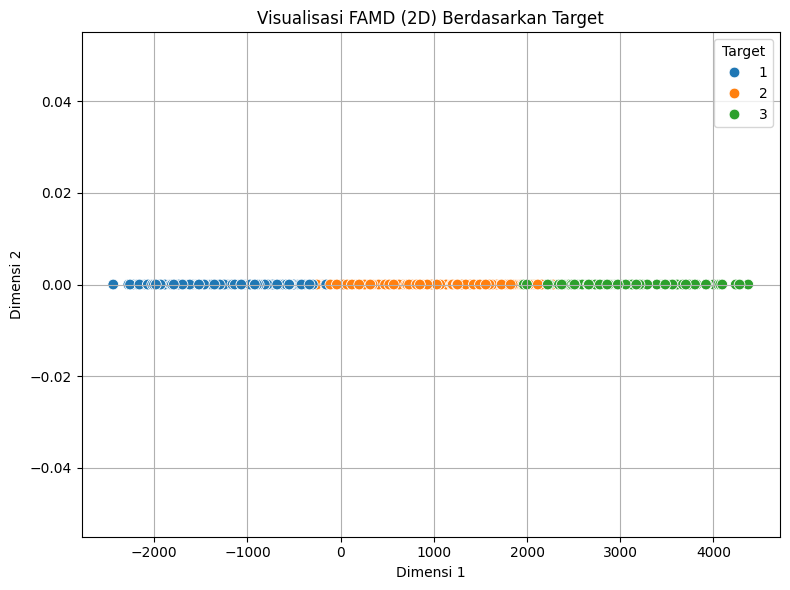

In [47]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=famd_df, x="Dim1", y="Dim2", hue="target", palette="tab10", s=60)

plt.title("Visualisasi FAMD (2D) Berdasarkan Target")
plt.xlabel("Dimensi 1")
plt.ylabel("Dimensi 2")
plt.legend(title="Target")
plt.grid(True)
plt.tight_layout()
plt.show()

Ada beberapa hal tambahan yang kami lakukan dalam tahap preposessing, selain mengaplikasikan suatu hal yang kami pikir terbaik seperti pembuatan fitur baru, kami melakukan beberapa method agar dataset lebih siap untuk diterima model, dan beberapa kesimpulan juga:

1. Stratified Split dengan proporsi 80 : 20
2. SMOTE Oversampling
3. FAMD untuk mereduksi dimensi Dataset
4. Fitur yang telah dipilih sudah cukup cocok melihat hasil plot data, bisa dilihat fitur menghasilkan plot data yang terkelompok dan hampir tidak ada label yang tercampur dengan label lain

# **III. Modeling**

## ***A. Model Application***

### 1. Model dengan Class

In [48]:
class KNN:
    def __init__(self, k=5, p=2):
        self.k = k
        self.p= p 

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def minkowski_distance(self, a, b):
        return np.sum(np.abs(a - b) ** self.p) ** (1 / self.p)
    
    def predict(self, X):
        X_test = X
        distances = np.zeros((X_test.shape[0], self.X_train.shape[0]))

        for i, test_point in enumerate(X_test):
            for j, train_point in enumerate(self.X_train):
                distances[i, j] = self.minkowski_distance(test_point, train_point)

        nearest_neighbors_indices = np.argsort(distances, axis=1)[:, :self.k]
        neighbors = np.array(self.y_train)[nearest_neighbors_indices]

        y_pred = []
        for neighbor_classes in neighbors:
            classes, counts = np.unique(neighbor_classes, return_counts=True)
            predicted_class = classes[np.argmax(counts)]
            y_pred.append(predicted_class)

        return np.array(y_pred)
    
    def plot_neighbors(self, input_point, y_train, zoom=False):
        distances = np.array([self.minkowski_distance(input_point, train_point) for train_point in self.X_train])
        nearest_neighbors_indices = np.argsort(distances)[:self.k]

        plt.figure(figsize=(12, 8))
        scatter = plt.scatter(self.X_train[:, 0], self.X_train[:, 1], c=y_train, cmap="coolwarm", alpha=0.7, label="Training Data")
        plt.colorbar(scatter, label="Class")

        plt.scatter(input_point[0], input_point[1], c="yellow", edgecolors="black", s=200, marker="*", label="Input Data")

        cmap = plt.cm.coolwarm
        norm = plt.Normalize(vmin=0, vmax=1)

        for i, idx in enumerate(nearest_neighbors_indices):
            neighbor_point = self.X_train[idx]
            color = cmap(norm(y_train[idx])) 
            label = "Nearest Neighbors" if i == 0 else None
            plt.scatter(neighbor_point[0], neighbor_point[1], facecolors=color, edgecolors="black", 
                        s=150, linewidth=2, label=label)
            plt.plot([input_point[0], neighbor_point[0]], 
                     [input_point[1], neighbor_point[1]], 
                     "black", linestyle="dashed", alpha=0.5)
            plt.text(neighbor_point[0]+0.01, neighbor_point[1]+0.01, f"{i+1}", fontsize=9, color="black")

        plt.xlabel("Dim 1 (FAMD)")
        plt.ylabel("Dim 2 (FAMD)")
        plt.title("FAMD Scatter Plot dengan Input dan K Nearest Neighbors")
        plt.legend()
        plt.grid(True)

        if zoom:
            all_x = [input_point[0]] + [self.X_train[idx][0] for idx in nearest_neighbors_indices]
            all_y = [input_point[1]] + [self.X_train[idx][1] for idx in nearest_neighbors_indices]

            x_padding = (max(all_x) - min(all_x)) * 0.2
            y_padding = (max(all_y) - min(all_y)) * 0.2

            plt.xlim(min(all_x) - x_padding, max(all_x) + x_padding)
            plt.ylim(min(all_y) - y_padding, max(all_y) + y_padding)

            print("Label Tetangga Terdekat:")
            for i, idx in enumerate(nearest_neighbors_indices):
                print(f"Tetangga ke-{i+1}: Label = {y_train[idx]}")

        plt.show()

### 2. Rule of Thumb

In [49]:
rule_of_thumb = round(np.sqrt(len(X_train_famd)))
rule_of_thumb

41

### 3. K Cross Validation 

In [50]:
train_accs = []
test_accs = []
k_values = range(1, 10)

for k in k_values:
    model = KNN(k=k, p=2)
    model.fit(X_train_famd, y_train)
    y_pred_train = model.predict(X_train_famd)
    y_pred_test = model.predict(X_test_famd)

    train_acc = np.mean(y_pred_train == y_train) * 100
    test_acc = np.mean(y_pred_test == y_test) * 100

    train_accs.append(train_acc)
    test_accs.append(test_acc)

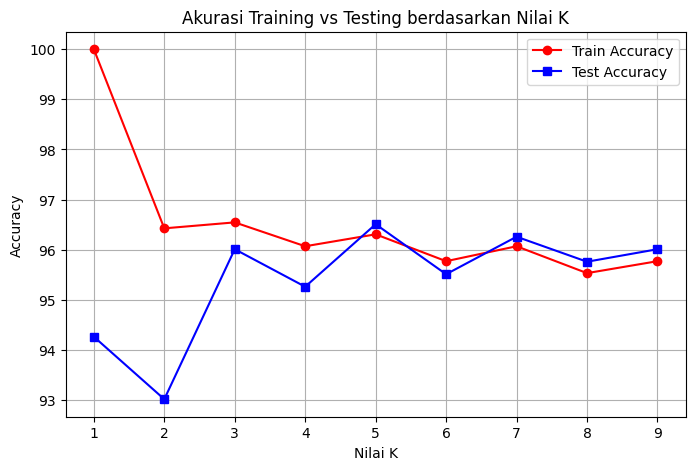

In [51]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, train_accs, marker="o", label="Train Accuracy", color="red")
plt.plot(k_values, test_accs, marker="s", label="Test Accuracy", color="blue")
plt.xlabel("Nilai K")
plt.ylabel("Accuracy")
plt.title("Akurasi Training vs Testing berdasarkan Nilai K")
plt.xticks(k_values)
plt.legend()
plt.grid()
plt.show()

### 4. Elbow Method

In [52]:
def error_rate(y_true, y_pred):
    return np.sum(y_true != y_pred) / len(y_true)

errors = []

for k in k_values:
    model = KNN(k=k, p=2)
    model.fit(X_train_famd, y_train)
    y_pred = model.predict(X_test_famd)
    error = error_rate(y_test, y_pred)
    errors.append(error)

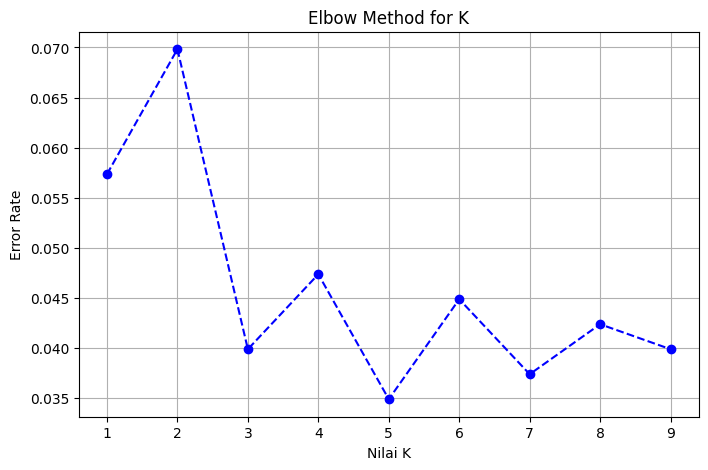

In [53]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, errors, marker="o", linestyle="dashed", color="b")
plt.xlabel("Nilai K")
plt.ylabel("Error Rate")
plt.title("Elbow Method for K")
plt.xticks(k_values)
plt.grid()
plt.show()

### 5. Pengaplikasian Model

In [54]:
model = KNN(k=5, p=2)
model.fit(X_train_famd, y_train)
y_pred_train = model.predict(X_train_famd)
y_pred_test = model.predict(X_test_famd)

## ***B. Visualisasi Model***

### 1. Uji Coba Data Baru

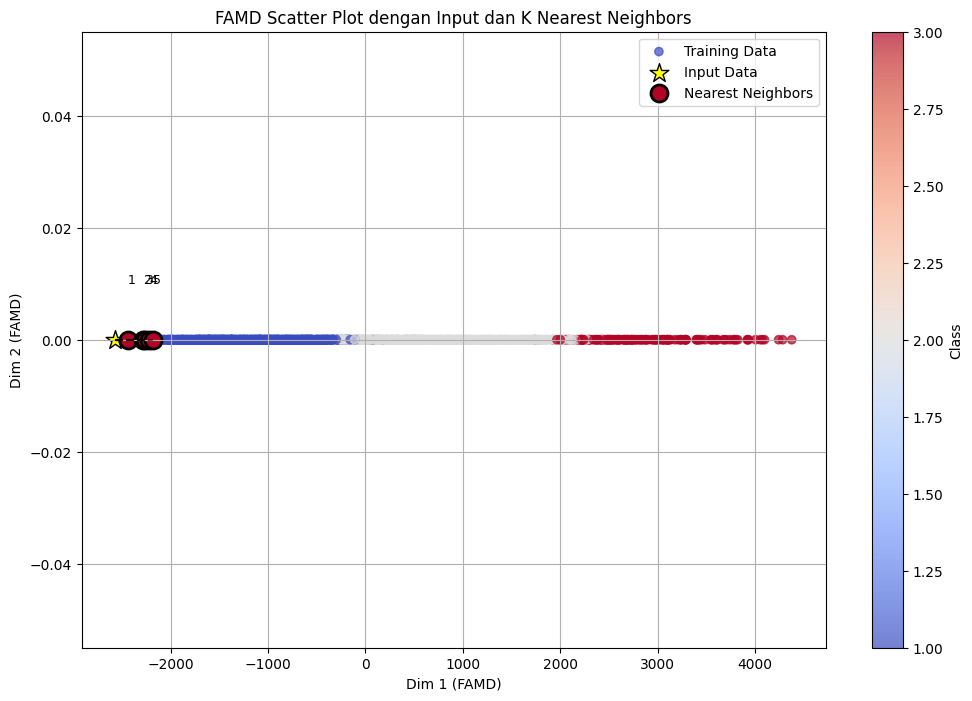

In [55]:
input_data = [900, 18, 3, 2, 5]
input_df = pd.DataFrame([input_data], columns=feature_cols)
input_famd = famd_transform_auto(input_df, famd_model)[0] 
model.plot_neighbors(input_famd, y_train, zoom=False)

C:\Users\RyzQ\AppData\Local\Temp\ipykernel_38752\486521057.py:70: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(min(all_y) - y_padding, max(all_y) + y_padding)


Label Tetangga Terdekat:
Tetangga ke-1: Label = 1
Tetangga ke-2: Label = 1
Tetangga ke-3: Label = 1
Tetangga ke-4: Label = 1
Tetangga ke-5: Label = 1


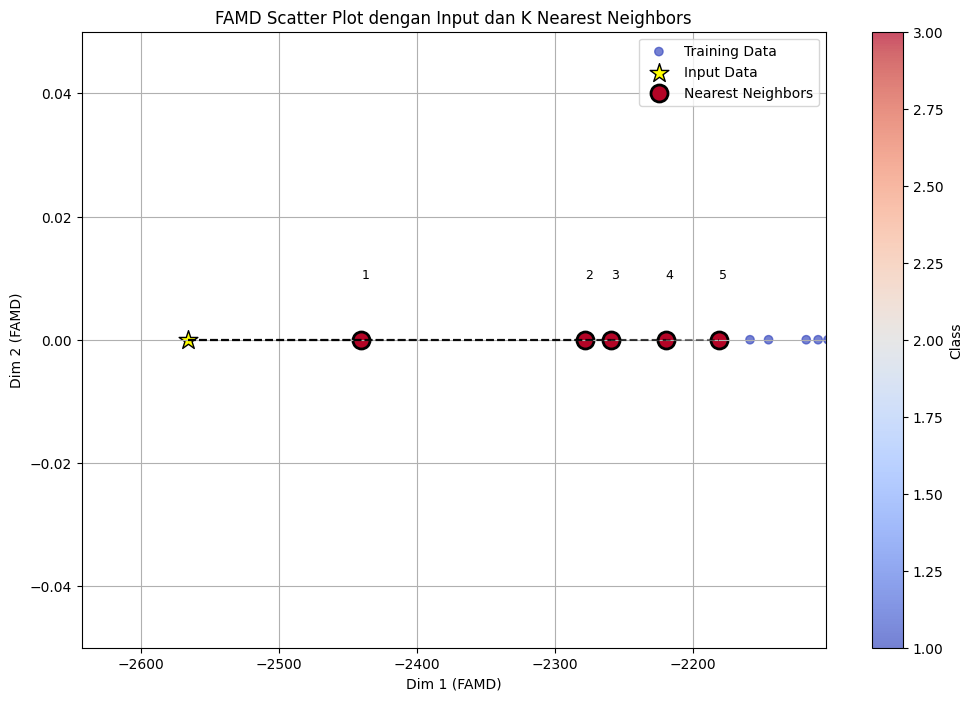

In [56]:
model.plot_neighbors(input_famd, y_train, zoom=True)

### 2. Reverse Encoding untuk Visualsasi

In [57]:
def reverse_mapping(mapping):
    return {v: k for k, v in mapping.items()}

reverse_map_target = reverse_mapping(map_target)
dataset["Target"] = dataset["Target"].map(reverse_map_target)

### 3. Distribusi Hasil Prediksi

#### *a. Training Model*

In [58]:
pred_train = pd.DataFrame({
    "Prediksi Training": y_pred_train,
    "Aktual Training": y_train})
# pred_train.to_csv("pred_train")
pred_train

,Prediksi Training,Aktual Training
0,1,1
1,2,1
2,1,1
3,1,1
4,2,2
...,...,...
1674,2,2
1675,2,2
1676,2,2
1677,3,3


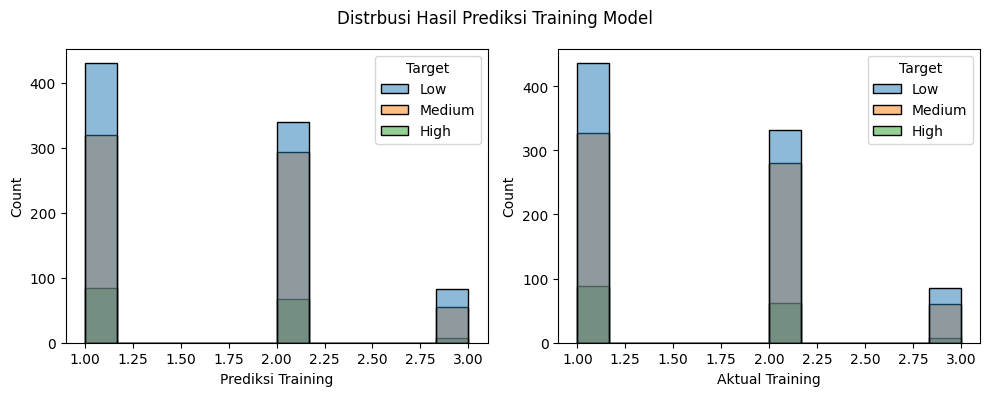

In [59]:
plt.figure(figsize=(10, 4))
for i, col in enumerate(pred_train):
    plt.subplot(1, 2, i+1)
    sns.histplot(x=pred_train[col], hue=dataset['Target'])

plt.suptitle("Distrbusi Hasil Prediksi Training Model")
plt.tight_layout()
plt.show()

In [60]:
for col in pred_train:
    print(f"Distribusi Kelas pada {col}:")
    print(pred_train[col].value_counts())
    print()

Distribusi Kelas pada Prediksi Training:
Prediksi Training
1    834
2    700
3    145
Name: count, dtype: int64

Distribusi Kelas pada Aktual Training:
Aktual Training
1    851
2    674
3    154
Name: count, dtype: int64



#### *b. Testing Model*

In [61]:
pred_test = pd.DataFrame({
    "Prediksi Testing": y_pred_test,
    "Aktual Testing": y_test})
# pred_test.to_csv("pred_test")
pred_test

,Prediksi Testing,Aktual Testing
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
...,...,...
396,3,3
397,3,3
398,3,3
399,3,3


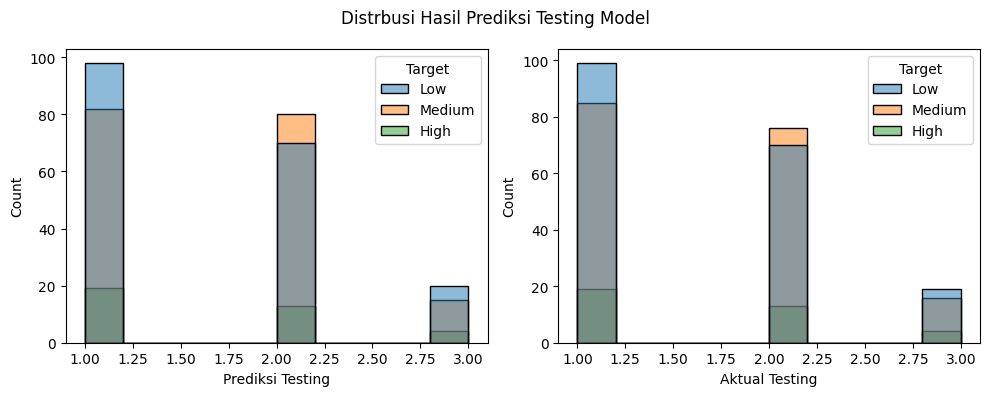

In [62]:
plt.figure(figsize=(10, 4))
for i, col in enumerate(pred_test):
    plt.subplot(1, 2, i+1)
    sns.histplot(x=pred_test[col], hue=dataset['Target'])

plt.suptitle("Distrbusi Hasil Prediksi Testing Model")
plt.tight_layout()
plt.show()

In [63]:
for col in pred_test.columns:
    print(f"Distribusi Kelas pada {col}:")
    print(pred_test[col].value_counts())
    print()

Distribusi Kelas pada Prediksi Testing:
Prediksi Testing
1    199
2    163
3     39
Name: count, dtype: int64

Distribusi Kelas pada Aktual Testing:
Aktual Testing
1    203
2    159
3     39
Name: count, dtype: int64



### 4. Confusion Matrix

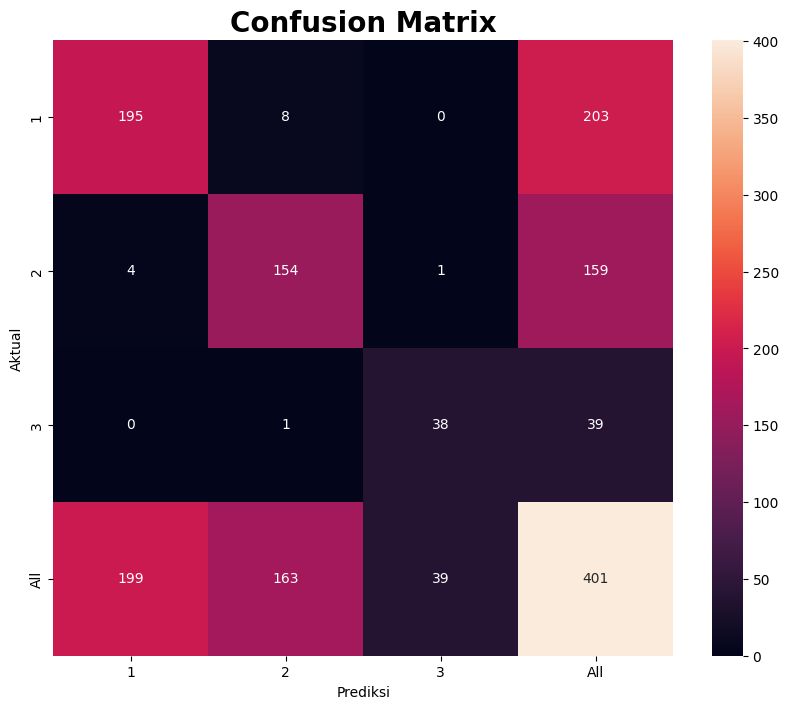

,1,2,3,All
1,195,8,0,203
2,4,154,1,159
3,0,1,38,39
All,199,163,39,401


In [64]:
data_confusion = pd.crosstab(y_test, y_pred_test, margins=True)
data_confusion.columns = data_confusion.columns.tolist()
data_confusion.index = data_confusion.index.tolist()
    
plt.figure(figsize=(10, 8))
plt.title('Confusion Matrix', size=20, weight='bold')
sns.heatmap(data_confusion, annot=True, fmt='d')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

display(data_confusion)

### 5. Analisis Korelasi Fitur dengan Fitur

#### *a. Fitur Numerik*

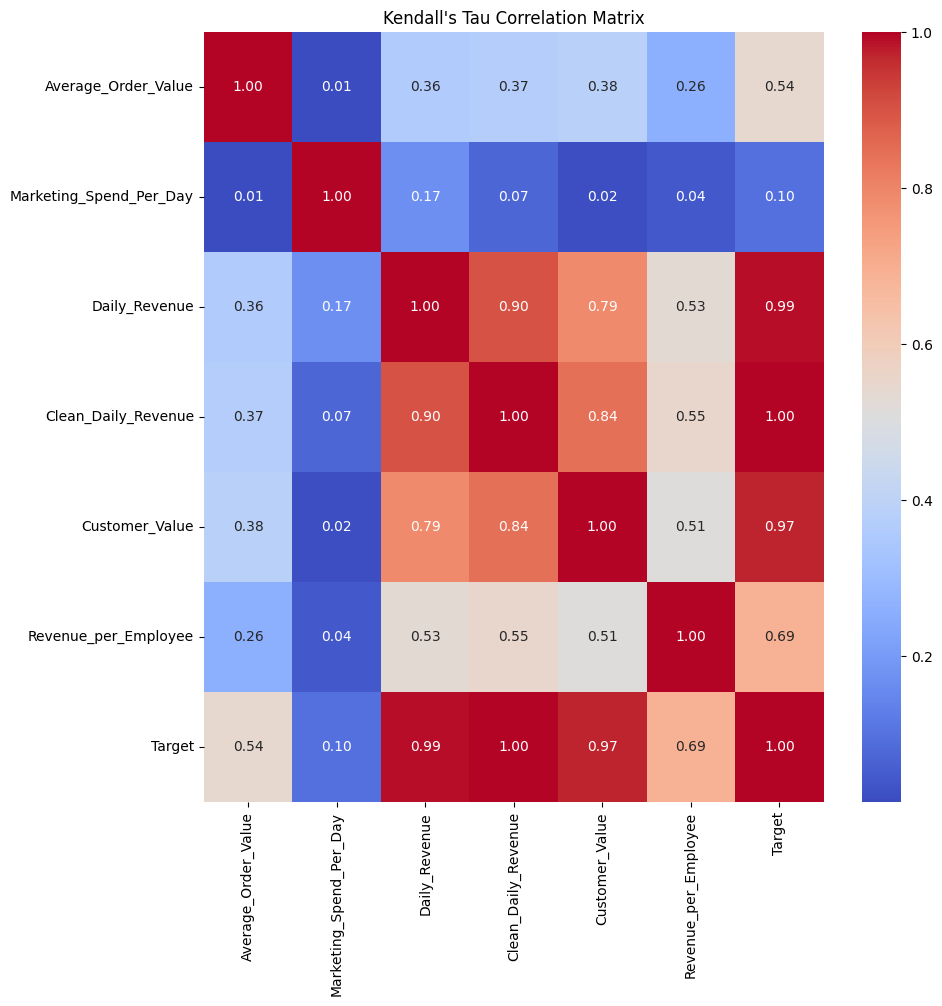

In [65]:
fitur_continu_real
corr_matrix = pd.DataFrame(index=fitur_continu_real, columns=fitur_continu_real)

for col1 in fitur_continu_real:
    for col2 in fitur_continu_real:
        corr_matrix.loc[col1, col2] = kendall_method(dataset_copy[col1].values, dataset_copy[col2].values)

corr_matrix = corr_matrix.astype(float)

plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix, cmap='coolwarm', fmt=".2f", annot=True)
plt.title("Kendall's Tau Correlation Matrix")
plt.show()

## ***D. Evaluasi Model***

### 1. Confusion Matrix

#### *a. Fungsi Confusion Matrix*

In [66]:
def confusion_matrix(y_true, y_pred, average):
    accuracy_array = []
    precision_array = []
    recall_array = []
    f1_array = []

    labels = np.unique(y_true)

    for label in labels:
        TP = np.sum((y_true == label) & (y_pred == label))
        FP = np.sum((y_true != label) & (y_pred == label))

        TN = np.sum((y_true != label) & (y_pred != label))
        FN = np.sum((y_true == label) & (y_pred != label))

        accuracy = (TP + TN) / (TP + TN + FP + FN) if  (TP + TN + FP + FN) != 0 else 0
        precision = TP / (TP + FP) if (TP + FP) != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall)

        accuracy_array.append(accuracy)
        precision_array.append(precision)
        recall_array.append(recall)
        f1_array.append(f1_score)

    if average == 'macro':
        accuracy = np.mean(accuracy_array)
        precision = np.mean(precision_array)
        recall = np.mean(recall_array)
        f1_score = np.mean(f1_array)

    elif average == "micro":
        TP = np.sum(y_true == y_pred)
        FP = np.sum((y_true != y_pred) & (y_pred != y_true))

        TN = np.sum(y_true == y_pred)
        FN  = np.sum((y_true == y_pred) & (y_true != y_pred))

        accuracy = (TP + TN) / (TP + TN + FP + FN) if  (TP + TN + FP + FN) != 0 else 0
        precision = TP / (TP + FP) if (TP + FP) != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall)
    
    return accuracy, precision, recall, f1_score

#### *b. Evaluasi Training Model*

In [67]:
acccuracy_train, precision_train, recall_train, f1_score_train = confusion_matrix(y_train, y_pred_train, average='macro')
print('-' * 30)
print(f"Akurasi train: {acccuracy_train:.2f}")
print('-' * 30)
print(f"Presisi train: {precision_train:.2f}")
print('-' * 30)
print(f"Recall train: {recall_train:.2f}")
print('-' * 30)
print(f"F1 Score train: {f1_score_train:.2f}")
print('-' * 30)

------------------------------
Akurasi train: 0.98
------------------------------
Presisi train: 0.96
------------------------------
Recall train: 0.95
------------------------------
F1 Score train: 0.95
------------------------------


#### *c. Evaluasi Testing Model*

In [68]:
acccuracy_test, precision_test, recall_test, f1_score_test = confusion_matrix(y_test, y_pred_test, average='macro')
print('-' * 30)
print(f"Akurasi test: {acccuracy_test:.2f}")
print('-' * 30)
print(f"Presisi test: {precision_test:.2f}")
print('-' * 30)
print(f"Recall test: {recall_test:.2f}")
print('-' * 30)
print(f"F1 Score test: {f1_score_test:.2f}")
print('-' * 30)

------------------------------
Akurasi test: 0.98
------------------------------
Presisi test: 0.97
------------------------------
Recall test: 0.97
------------------------------
F1 Score test: 0.97
------------------------------


### 2. Bias dan Variance Model

In [69]:
bias_knn = 1 - acccuracy_test
variance_knn = acccuracy_train - acccuracy_test

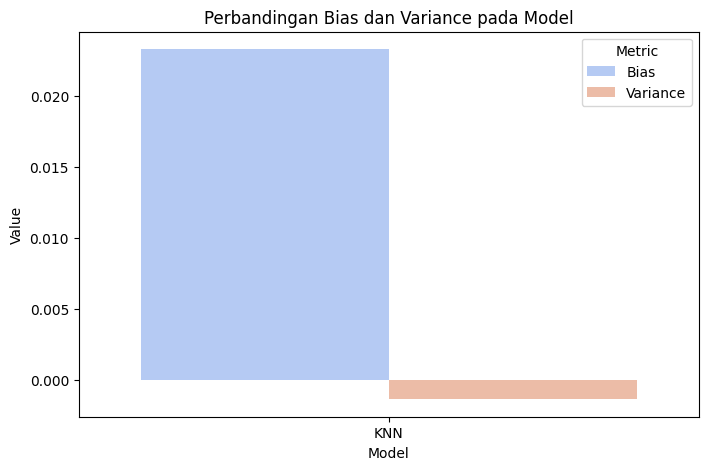

In [70]:
data = {
    "Model": ["KNN", "KNN"],
    "Metric": ["Bias", "Variance"],
    "Value": [bias_knn, variance_knn]
}
df = pd.DataFrame(data)

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Model", y="Value", hue="Metric", palette="coolwarm")

plt.xlabel("Model")
plt.ylabel("Value")
plt.title("Perbandingan Bias dan Variance pada Model")
plt.legend(title="Metric")

plt.show()

### 3. K-Fold Cross Validation

#### *a. Fungsi K-Fold*

In [71]:
def stratified_k_fold(X, y, model, k=7):
    unique_classes, counts = np.unique(y, return_counts=True)
    class_indices = {cls: np.where(y == cls)[0] for cls in unique_classes}
    folds = [[] for _ in range(k)]

    for cls, indices in class_indices.items():
        np.random.shuffle(indices)
        fold_sizes = np.array_split(indices, k)
        for i in range(k):
            folds[i].extend(fold_sizes[i])

    accuracies = []

    for i in range(k):
        train_idx = np.hstack([[j] for j in range(k) if j != i])
        test_idx = np.array(folds[i])

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accuracy, _, _, _ = confusion_matrix(y_test, y_pred, average='macro')
        accuracies.append(accuracy)

        print(f"Fold: {i + 1} | Accuracy: {accuracy:.2f}")
    
    avg_acc = np.mean(accuracies)
    std_dev = np.std(accuracies)

    print(f"Average Accuracy Between Folds: {avg_acc:.2f}")
    print(f"Total Standard Deviation: {std_dev:.2f}")

    return avg_acc, std_dev

#### *b. Model K-Fold*

In [72]:
k_fold = stratified_k_fold(X_test_famd, y_test, model, k=5)

Fold: 1 | Accuracy: 0.67
Fold: 2 | Accuracy: 0.67
Fold: 3 | Accuracy: 0.67
Fold: 4 | Accuracy: 0.67
Fold: 5 | Accuracy: 0.68
Average Accuracy Between Folds: 0.67
Total Standard Deviation: 0.00


C:\Users\RyzQ\AppData\Local\Temp\ipykernel_38752\2303464333.py:19: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * (precision * recall) / (precision + recall)
C:\Users\RyzQ\AppData\Local\Temp\ipykernel_38752\2303464333.py:19: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * (precision * recall) / (precision + recall)
C:\Users\RyzQ\AppData\Local\Temp\ipykernel_38752\2303464333.py:19: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * (precision * recall) / (precision + recall)
C:\Users\RyzQ\AppData\Local\Temp\ipykernel_38752\2303464333.py:19: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * (precision * recall) / (precision + recall)
C:\Users\RyzQ\AppData\Local\Temp\ipykernel_38752\2303464333.py:19: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * (precision * recall) / (precision + recall)


## **IV. Final Evaluation**

Berbagai proses telah dilakukan dan berikut beberapa hal yang bisa kami tarik sebagai kesimpulan:

1. Model KNN sudah bisa memberikan hasil prediksi yang konsisten dan akurat, namun jika dimasukkan data baru diluar dataset, model masih belum siap.

2. Faktor yang mempengaruhi revenue suatu coffee shop adalah jumlah customer per harinya, berapa budget marketing yang dikeluarkan per bulan, berapa transaksi yang dihasilkan pelanggan dan berapa revenue yang didapatkan tiap hari.

3. Marketing belum tentu bisa menentukan berapa banyak pelanggan yang akan datang, namun ia tetap bisa menjamin revenue suatu coffee shop.

4. Jarak penghasilan bersih dengan penghasilan kotor tidak jauh berbeda, dikarenakan biaya yang dikeluarkan untuk marketing tidak sebanyak itu.

5. Kemungkinan besar, pencinta kopi di daerah tersebut lebih berpatok kepada selera masing masing (entah itu kopi ataupun toko kopi yang didatangi) karena mereka tidak terlalu berpengaruh terhadap marketing yang diberikan.

6. Bidang wirausaha coffee shop disana berkembang dengan pesat, terbukti dari hasil dari setiap toko yang kebanyakn memiliki revenue yang tinggi

---

Saran yang bisa kami berikan kepada para coffee show owner:

1. Sebagai owner dari sebuah coffee shop, Anda perlu mengetahui faktor-faktor yang mempengaruhi revenue dan yang mempengaruhi berapa banyak customer yang datang ke coffee shop Anda. 

2. Faktor yang mempengaruhi revenue adalah berapa banyak budget yang dikeluarkan untuk marketing, namun perlu diingat bahwa ia belum tentu dapat menentukan banyaknya customer yang akan datang. 

3. Marketing yang dilakukan belum tentu bisa menentukan banyaknya customer yang akan datang. Sebagai asumsi, kemungkinan karena kebanyakan customer sudah nyaman di coffee shop langganan mereka sehingga ketertarikan mereka untuk mencoba toko lain kecil. Namun dengan marketing, Anda akan dapat menarik customer yang sudah berlangganan di toko lain untuk mencoba di toko Anda, yang nantinya akan disebarkan kabarnya dari mulut ke mulut lalu circle customer tersebut akan ikut tertarik mencoba di toko Anda.

---